# Multiclass Sentiment Analysis: From Classical ML to Transformers
### Predicting Yelp Star Ratings (1-5) — A Comparative Architecture Study on the Full ~7M-Review Dataset

**Task:** 5-class classification — predict the exact star rating (1-5) a review corresponds to,
rather than a coarser binary positive/negative label. This is a substantially harder task than
binary sentiment: adjacent classes (e.g. 3-star vs 4-star) are lexically and semantically close,
so this setup is designed to actually reveal performance differences between simple ML baselines
and deep learning architectures — a binary split tends to compress every model into a narrow,
uninformative F1 band (0.96-0.99), while 5-class prediction has real room for models to differ.

**Pipeline:** EDA -> Preprocessing -> Model Training (ML baselines, RNN, LSTM, GRU [multi-layer],
Seq2Seq, Seq2Seq+Bahdanau Attention, Seq2Seq+Luong Attention, Fine-tuned BERT) -> Metrics ->
TOPSIS-based Model Ranking -> Error Analysis

**Hardware target:** NVIDIA H100 GPU

**Dataset:** [Yelp Open Dataset](https://www.yelp.com/dataset) — ~6,990,280 business reviews with
1-5 star ratings and review text. Distributed as `yelp_academic_dataset_review.json` (one JSON
object per line). **No rows are dropped here** — since we predict the exact star rating rather
than collapsing to binary sentiment, every review (including former "neutral" 3-star reviews) is
retained, giving the full dataset for training.

**Setup:** Download from https://www.yelp.com/dataset (accept Yelp's terms), extract, and set
`YELP_JSON_PATH` below.


## 0. Environment Setup & Configuration

In [1]:
!pip install -q transformers torch scikit-learn pandas numpy matplotlib seaborn wordcloud tqdm


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
import os, re, json, time, math, random, string, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              roc_auc_score, confusion_matrix, classification_report)
from sklearn.preprocessing import label_binarize

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True

os.makedirs("weights", exist_ok=True)
os.makedirs("outputs", exist_ok=True)
METRICS_CSV = "outputs/model_metrics.csv"
N_CLASSES = 5   # star ratings 1-5, encoded internally as labels 0-4


Device: cuda
GPU: NVIDIA H100 80GB HBM3 MIG 3g.40gb


In [3]:
# ============================================================
# CONFIG
# ============================================================
YELP_JSON_PATH = "yelp_academic_dataset_review.json"

# Using the FULL dataset everywhere -- no subsampling. ML baselines (TF-IDF) and DL models
# both train on the entire ~7M reviews (minus exact duplicates).
ML_SAMPLE_SIZE = None
DL_SAMPLE_SIZE = None

MAX_SEQ_LEN   = 200
BERT_MAX_LEN  = 256
VOCAB_SIZE    = 50_000
EMBED_DIM     = 300
BATCH_SIZE    = 256
BERT_BATCH_SIZE = 256
EPOCHS_DL     = 15
EPOCHS_BERT   = 10
LR_DL         = 1e-3
LR_BERT       = 2e-5
RNN_LAYERS    = 2      # multi-layer RNN/LSTM/GRU depth
HIDDEN_DIM    = 256

print("Config loaded.")


Config loaded.


## 1. Data Loading

In [4]:
def load_yelp_reviews(path, max_rows=None):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(tqdm(f, desc="Loading Yelp reviews")):
            if max_rows is not None and i >= max_rows:
                break
            try:
                obj = json.loads(line)
                rows.append({"text": obj["text"], "stars": obj["stars"]})
            except (json.JSONDecodeError, KeyError):
                continue
    return pd.DataFrame(rows)

df_raw = load_yelp_reviews(YELP_JSON_PATH, max_rows=ML_SAMPLE_SIZE)
print(f"Loaded {len(df_raw):,} reviews")
df_raw.head()


Loading Yelp reviews: 6990280it [00:28, 243186.60it/s]


Loaded 6,990,280 reviews


,text,stars
0,"If you decide to eat here, just be aware it is...",3.0
1,I've taken a lot of spin classes over the year...,5.0
2,Family diner. Had the buffet. Eclectic assortm...,3.0
3,"Wow! Yummy, different, delicious. Our favo...",5.0
4,Cute interior and owner (?) gave us tour of up...,4.0


In [5]:
# 5-class label = star rating - 1 (so labels are 0-4, matching PyTorch's expected 0-indexed
# class convention). NO rows are dropped for label reasons -- every star rating 1-5 is a
# valid class. We DO still remove exact duplicate review texts, since duplicates would leak
# identical samples across train/val/test after a random split.
df_raw["stars"] = df_raw["stars"].astype(int)
df_raw = df_raw[df_raw["stars"].between(1, 5)]  # safety: drop any malformed rating values
df_raw["label"] = (df_raw["stars"] - 1).astype(int)  # 0=1-star ... 4=5-star

df = df_raw.drop_duplicates(subset=["text"]).reset_index(drop=True)

print(f"After removing duplicates: {len(df):,} reviews (full dataset retained -- no class dropped)")
print(df["stars"].value_counts().sort_index())
print()
print(df["label"].value_counts(normalize=True).sort_index())


After removing duplicates: 6,974,127 reviews (full dataset retained -- no class dropped)
stars
1    1066238
2     543250
3     690785
4    1450273
5    3223581
Name: count, dtype: int64

label
0    0.152885
1    0.077895
2    0.099050
3    0.207950
4    0.462220
Name: proportion, dtype: float64


## 2. Exploratory Data Analysis

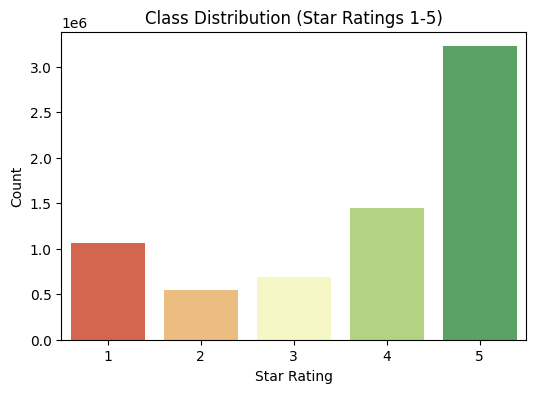

Per-class counts:
stars
1    1066238
2     543250
3     690785
4    1450273
5    3223581
Name: count, dtype: int64

Per-class share (%):
stars
1    15.29
2     7.79
3     9.90
4    20.80
5    46.22
Name: count, dtype: float64

Majority:minority ratio (5-star : 2-star) = 5.93 : 1


In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x="stars", data=df, order=[1,2,3,4,5], palette="RdYlGn")
plt.title("Class Distribution (Star Ratings 1-5)")
plt.xlabel("Star Rating")
plt.ylabel("Count")
plt.savefig("outputs/eda_class_balance.png", dpi=150, bbox_inches="tight")
plt.show()

# Quantify the imbalance explicitly -- Yelp skews heavily toward 5-star reviews, so a 5-class
# setup is significantly MORE imbalanced than the binary collapse was (5-star alone is roughly
# half of all reviews, while 2-star and 3-star are comparatively rare).
class_counts = df["stars"].value_counts().sort_index()
print("Per-class counts:")
print(class_counts)
print()
print("Per-class share (%):")
print((100 * class_counts / class_counts.sum()).round(2))
print()
print(f"Majority:minority ratio (5-star : 2-star) = "
      f"{class_counts[5] / class_counts[2]:.2f} : 1")


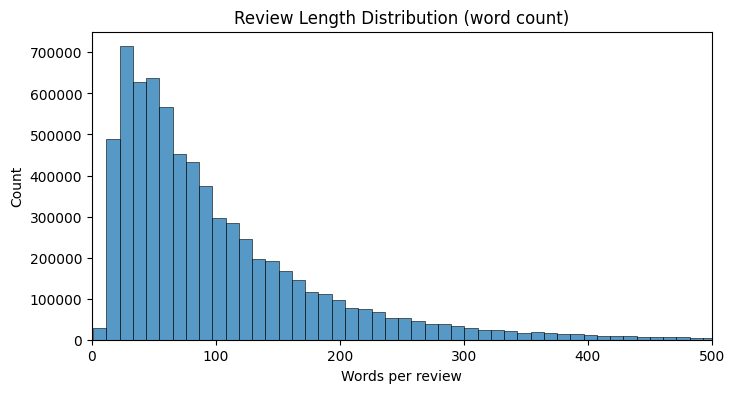

count    6.974127e+06
mean     1.047787e+02
std      9.790970e+01
min      1.000000e+00
25%      4.200000e+01
50%      7.500000e+01
75%      1.330000e+02
max      1.070000e+03
Name: word_count, dtype: float64
95th percentile: 290 words
99th percentile: 489 words


In [7]:
df["word_count"] = df["text"].str.split().apply(len)

plt.figure(figsize=(8,4))
sns.histplot(df["word_count"], bins=100)
plt.xlim(0, 500)
plt.title("Review Length Distribution (word count)")
plt.xlabel("Words per review")
plt.savefig("outputs/eda_length_dist.png", dpi=150, bbox_inches="tight")
plt.show()

print(df["word_count"].describe())
print(f"95th percentile: {df['word_count'].quantile(0.95):.0f} words")
print(f"99th percentile: {df['word_count'].quantile(0.99):.0f} words")


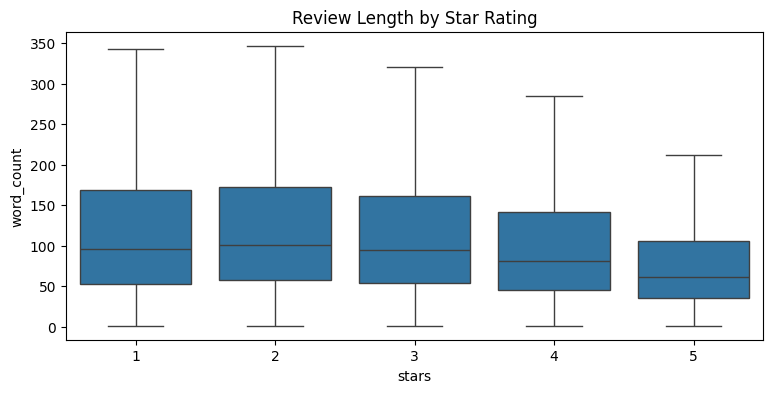

In [8]:
plt.figure(figsize=(9,4))
sns.boxplot(x="stars", y="word_count", data=df, order=[1,2,3,4,5], showfliers=False)
plt.title("Review Length by Star Rating")
plt.savefig("outputs/eda_length_by_class.png", dpi=150, bbox_inches="tight")
plt.show()


In [9]:
from sklearn.feature_extraction.text import CountVectorizer

def top_ngrams(texts, n=1, top_k=12):
    vec = CountVectorizer(ngram_range=(n,n), stop_words="english", max_features=20000)
    X = vec.fit_transform(texts.sample(min(len(texts), 100_000), random_state=SEED))
    freqs = np.asarray(X.sum(axis=0)).flatten()
    vocab = vec.get_feature_names_out()
    top_idx = freqs.argsort()[-top_k:][::-1]
    return [(vocab[i], freqs[i]) for i in top_idx]

for star in [1, 2, 3, 4, 5]:
    print(f"Top unigrams — {star}-star reviews:")
    for word, freq in top_ngrams(df[df.stars==star]["text"], n=1, top_k=10):
        print(f"  {word}: {freq}")
    print()


Top unigrams — 1-star reviews:
  food: 48152
  time: 43748
  just: 43561
  service: 43454
  place: 40835
  like: 36764
  told: 35177
  said: 34804
  order: 29450
  don: 28691

Top unigrams — 2-star reviews:
  food: 74294
  good: 54921
  just: 51915
  like: 48783
  place: 48075
  service: 41951
  time: 41347
  ordered: 30813
  really: 29269
  got: 27470

Top unigrams — 3-star reviews:
  good: 80553
  food: 70923
  place: 51204
  just: 48469
  like: 47080
  service: 37415
  great: 35139
  time: 34933
  really: 33285
  nice: 25774

Top unigrams — 4-star reviews:
  good: 73406
  food: 56601
  great: 54807
  place: 50119
  like: 35265
  just: 31138
  really: 30698
  service: 30274
  time: 30181
  nice: 26059

Top unigrams — 5-star reviews:
  great: 55932
  food: 43375
  place: 42785
  good: 35209
  service: 28389
  time: 27250
  best: 24840
  just: 22620
  like: 21345
  amazing: 21016



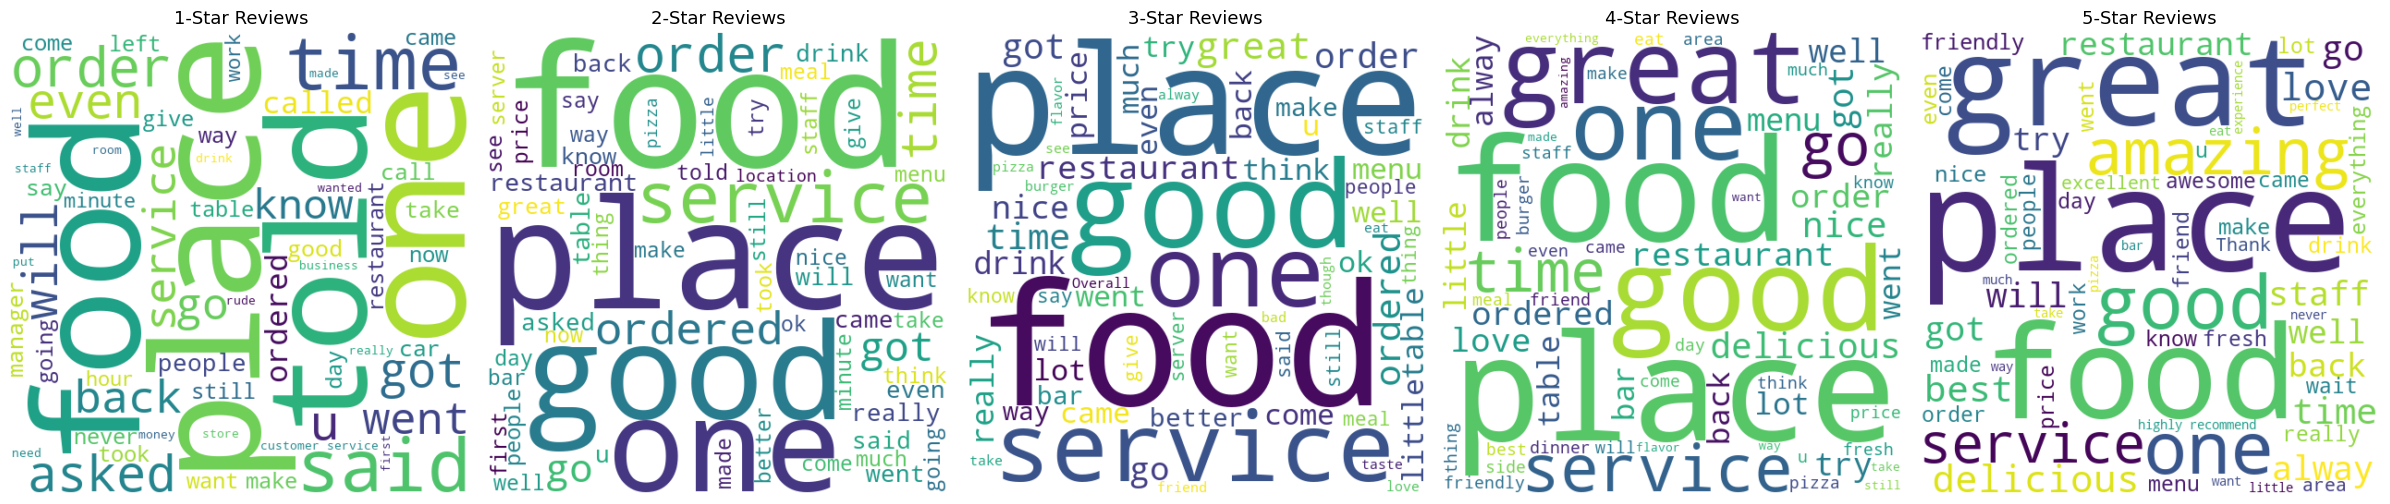

In [10]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 5, figsize=(24,5))
for ax, star in zip(axes, [1,2,3,4,5]):
    subset = df[df.stars==star]["text"]
    sample_text = " ".join(subset.sample(min(20000, len(subset)), random_state=SEED))
    wc = WordCloud(width=500, height=500, background_color="white", max_words=60).generate(sample_text)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"{star}-Star Reviews", fontsize=13)
    ax.axis("off")
plt.tight_layout()
plt.savefig("outputs/eda_wordclouds.png", dpi=150, bbox_inches="tight")
plt.show()


In [11]:
for star in [1, 3, 5]:
    print(f"=== Sample {star}-star reviews ===")
    for t in df[df.stars==star]["text"].sample(2, random_state=SEED):
        print("-", t[:200], "...\n")


=== Sample 1-star reviews ===
- Service is great, we had Megan who's studying to be an ultra sound tech and she was a sweetheart. 
I ordered zucchini fries as my app, they were fair, the batter is bland, I've had better but with a s ...

- One star. Nobody wearing gloves. People at the register were rude as hell when I asked them to put gloves on. No exaggeration. She made a face and looked at me like I just insulted her family. Automat ...

=== Sample 3-star reviews ===
- Ok fare. Reliable and consistent. Better than pizzeria beddia bugs because I don't have to wait three hours for my pie. ...

- Tried the new blackberry ribs and they were pretty dam good. bbq beans are good, mash potatoes are good. Shit just get the platter and your belly will be happy until the next day, plus you might even  ...

=== Sample 5-star reviews ===
- This is my first but definitely not my last visit! The sales girls were super friendly and informative and gave me several samples. I can't wait to try them 

## 3. Preprocessing

In [12]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-z0-9\s']", " ", text)   # keep apostrophes -> preserves negations (don't, isn't)
    text = re.sub(r"\s+", " ", text).strip()
    return text

tqdm.pandas()
df["clean_text"] = df["text"].progress_apply(clean_text)
df[["text", "clean_text", "stars", "label"]].head()


100%|██████████| 6974127/6974127 [03:16<00:00, 35413.31it/s]


,text,clean_text,stars,label
0,"If you decide to eat here, just be aware it is...",if you decide to eat here just be aware it is ...,3,2
1,I've taken a lot of spin classes over the year...,i've taken a lot of spin classes over the year...,5,4
2,Family diner. Had the buffet. Eclectic assortm...,family diner had the buffet eclectic assortmen...,3,2
3,"Wow! Yummy, different, delicious. Our favo...",wow yummy different delicious our favorite is ...,5,4
4,Cute interior and owner (?) gave us tour of up...,cute interior and owner gave us tour of upcomi...,4,3


In [13]:
# Stratified train/val/test split (70/15/15) on the 5-class label, used consistently across ALL models
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["label"], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED)

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
train_df["label"].value_counts(normalize=True).sort_index()


Train: 4,881,888 | Val: 1,046,119 | Test: 1,046,120


label
0    0.152885
1    0.077895
2    0.099050
3    0.207950
4    0.462220
Name: proportion, dtype: float64

### Handling Class Imbalance (5-Class)

5-star reviews dominate the dataset, and 2-star/3-star reviews are comparatively rare — a
5-class setup is meaningfully MORE imbalanced than the earlier binary collapse. We compute
**inverse-frequency class weights** (one weight per star rating) from the training split and
apply them consistently across every model:
- **Sklearn linear models** (LogReg, SVM): `class_weight="balanced"`
- **PyTorch models** (RNN/LSTM/GRU/Seq2Seq/attention): per-class weights in `CrossEntropyLoss`
- **BERT**: per-class weights in a weighted `CrossEntropyLoss`

Naive Bayes has no native class-weighting mechanism (it models class priors directly from
data), so we leave it as-is and note this as a known limitation for that specific baseline.


In [14]:
# Class weights computed ONCE from the training split, reused by every model below.
train_label_counts = train_df["label"].value_counts().sort_index()
total = train_label_counts.sum()

# Inverse-frequency weighting: weight_c = total / (n_classes * count_c)
class_weight_map = {c: total / (N_CLASSES * count) for c, count in train_label_counts.items()}
print("Class weights (train split, by 0-indexed label):", class_weight_map)

# Ordered tensor [w_class0, w_class1, ..., w_class4] for CrossEntropyLoss -- used by every
# PyTorch model (RNN/LSTM/GRU/Seq2Seq/attention) AND by BERT.
CLASS_WEIGHTS = torch.tensor(
    [class_weight_map[c] for c in range(N_CLASSES)], dtype=torch.float32
).to(DEVICE)
print("CLASS_WEIGHTS tensor:", CLASS_WEIGHTS.tolist())

# For sklearn models
SKLEARN_CLASS_WEIGHT = "balanced"


Class weights (train split, by 0-indexed label): {0: 1.3081735928839298, 1: 2.5675566366445337, 2: 2.0191906094315155, 3: 0.9617673915548897, 4: 0.4326944399881941}
CLASS_WEIGHTS tensor: [1.3081735372543335, 2.567556619644165, 2.019190549850464, 0.9617673754692078, 0.4326944351196289]


In [15]:
val_df_dl  = val_df
test_df_dl = test_df
train_df_dl = train_df   # full dataset used everywhere -- DL_SAMPLE_SIZE is None

print(f"DL training set: {len(train_df_dl):,} reviews (full training split, no subsampling)")


DL training set: 4,881,888 reviews (full training split, no subsampling)


## 4. Metrics Utility (shared across all models)

For 5-class prediction we use **macro-averaged** Precision/Recall/F1 (treats all 5 star
ratings equally regardless of class size — important here since 5-star reviews dominate and
macro-averaging prevents that majority class from hiding poor performance on 2-star/3-star
reviews) and **multiclass ROC-AUC** (one-vs-rest, macro-averaged). We also track training
time, inference time, and parameter count for every model, appending results to one shared
CSV (`outputs/model_metrics.csv`).


In [16]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def evaluate_predictions_multiclass(y_true, y_pred, y_prob=None, n_classes=5):
    """
    y_true, y_pred: 1D arrays of 0-indexed class labels (0-4)
    y_prob: 2D array (n_samples, n_classes) of predicted class probabilities, or None
    """
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0, labels=list(range(n_classes))
    )
    auc = np.nan
    if y_prob is not None:
        try:
            auc = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro",
                                 labels=list(range(n_classes)))
        except ValueError:
            auc = np.nan  # can happen if a class is entirely absent from y_true in a tiny test slice
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "roc_auc": auc}

def log_metrics(model_name, metrics_dict, train_time_s, inference_time_per_sample_ms,
                 n_params, model_size_mb):
    row = {
        "model": model_name,
        "accuracy": metrics_dict["accuracy"],
        "precision": metrics_dict["precision"],
        "recall": metrics_dict["recall"],
        "f1": metrics_dict["f1"],
        "roc_auc": metrics_dict["roc_auc"],
        "train_time_s": train_time_s,
        "inference_ms_per_sample": inference_time_per_sample_ms,
        "n_params": n_params,
        "model_size_mb": model_size_mb,
    }
    if os.path.exists(METRICS_CSV):
        existing = pd.read_csv(METRICS_CSV)
        existing = existing[existing["model"] != model_name]  # overwrite if rerun
        updated = pd.concat([existing, pd.DataFrame([row])], ignore_index=True)
    else:
        updated = pd.DataFrame([row])
    updated.to_csv(METRICS_CSV, index=False)
    print(f"Logged metrics for '{model_name}':")
    print(pd.DataFrame([row]).to_string(index=False))
    return row

def save_best_weights(model, path):
    """Save ONLY the state_dict (weights), not the full model object."""
    torch.save(model.state_dict(), path)
    size_mb = os.path.getsize(path) / (1024 ** 2)
    print(f"Saved weights -> {path} ({size_mb:.2f} MB)")
    return size_mb


## 5. ML Baselines: Logistic Regression, Naive Bayes, Linear SVM (Multiclass)

TF-IDF features, trained on the full stratified training split. All three models use
sklearn's native multiclass handling (`LogisticRegression` and `MultinomialNB` support
multinomial/OvR natively; `LinearSVC` uses one-vs-rest internally for multiclass).


In [17]:
tfidf = TfidfVectorizer(max_features=100_000, ngram_range=(1,2), min_df=3)
X_train_tfidf = tfidf.fit_transform(train_df["clean_text"])
X_val_tfidf   = tfidf.transform(val_df["clean_text"])
X_test_tfidf  = tfidf.transform(test_df["clean_text"])

y_train = train_df["label"].values
y_val   = val_df["label"].values
y_test  = test_df["label"].values

print("TF-IDF matrix shape (train):", X_train_tfidf.shape)


TF-IDF matrix shape (train): (4881888, 100000)


In [18]:
import pickle

def train_eval_sklearn(name, clf, X_train, y_train, X_test, y_test, has_proba=True):
    t0 = time.time()
    clf.fit(X_train, y_train)
    train_time = time.time() - t0

    t0 = time.time()
    y_pred = clf.predict(X_test)
    if has_proba:
        y_prob = clf.predict_proba(X_test)
    else:
        # LinearSVC has no predict_proba; use decision_function + softmax as a probability proxy
        scores = clf.decision_function(X_test)  # (n_samples, n_classes) for multiclass
        exp_scores = np.exp(scores - scores.max(axis=1, keepdims=True))
        y_prob = exp_scores / exp_scores.sum(axis=1, keepdims=True)
    inf_time_ms = (time.time() - t0) / len(y_test) * 1000

    metrics = evaluate_predictions_multiclass(y_test, y_pred, y_prob, n_classes=N_CLASSES)

    # "weights" for sklearn models = pickled model; save only the fitted estimator
    weight_path = f"weights/{name}.pkl"
    with open(weight_path, "wb") as f:
        pickle.dump(clf, f)
    size_mb = os.path.getsize(weight_path) / (1024 ** 2)

    n_params = X_train.shape[1] * N_CLASSES  # feature count x classes, proxy for "params" in linear models
    log_metrics(name, metrics, train_time, inf_time_ms, n_params, size_mb)
    return clf, y_pred, y_prob


In [19]:
logreg = LogisticRegression(max_iter=200, C=1.0, class_weight=SKLEARN_CLASS_WEIGHT)
# NOTE: `multi_class` was removed in scikit-learn >=1.5 (lbfgs solver now auto-handles
# multinomial/softmax classification whenever y has >2 classes) and `n_jobs` has no effect
# since sklearn 1.8 for this solver -- both omitted here to avoid FutureWarnings while
# remaining correct on both older and newer sklearn versions.
logreg, logreg_preds, logreg_probs = train_eval_sklearn(
    "LogisticRegression", logreg, X_train_tfidf, y_train, X_test_tfidf, y_test, has_proba=True
)


Logged metrics for 'LogisticRegression':
             model  accuracy  precision   recall       f1  roc_auc  train_time_s  inference_ms_per_sample  n_params  model_size_mb
LogisticRegression  0.698617   0.632987 0.656372 0.641329  0.91803   1312.388361                 0.001494    500000       3.815458


In [20]:
# NOTE: MultinomialNB has no class_weight parameter -- it estimates class priors directly
# from training data, so it naturally reflects the imbalance rather than correcting for it.
# This is a known limitation of this baseline, kept as-is for a fair "vanilla NB" comparison.
nb_clf = MultinomialNB()
nb_clf, nb_preds, nb_probs = train_eval_sklearn(
    "NaiveBayes", nb_clf, X_train_tfidf, y_train, X_test_tfidf, y_test, has_proba=True
)


Logged metrics for 'NaiveBayes':
     model  accuracy  precision   recall       f1  roc_auc  train_time_s  inference_ms_per_sample  n_params  model_size_mb
NaiveBayes   0.67297   0.575454 0.554355 0.559034 0.888328      3.647745                 0.001384    500000       7.630056


In [21]:
svm_clf = LinearSVC(C=1.0, max_iter=2000, class_weight=SKLEARN_CLASS_WEIGHT, dual=False)
svm_clf, svm_preds, svm_probs = train_eval_sklearn(
    "LinearSVM", svm_clf, X_train_tfidf, y_train, X_test_tfidf, y_test, has_proba=False
)


Logged metrics for 'LinearSVM':
    model  accuracy  precision   recall       f1  roc_auc  train_time_s  inference_ms_per_sample  n_params  model_size_mb
LinearSVM  0.715898   0.628157 0.634644 0.630752 0.912902   2681.090404                 0.001441    500000       3.815343


## 6. Vocabulary & PyTorch Dataset for RNN-family Models

Built once and shared across RNN, LSTM, GRU, and the Seq2Seq/attention models. Labels are
now 5-way (0-4) integer class indices instead of binary floats.


In [22]:
def build_vocab(texts, vocab_size=VOCAB_SIZE):
    counter = Counter()
    for t in tqdm(texts, desc="Building vocab"):
        counter.update(t.split())
    most_common = counter.most_common(vocab_size - 2)  # reserve <PAD>, <UNK>
    vocab = {"<PAD>": 0, "<UNK>": 1}
    for word, _ in most_common:
        vocab[word] = len(vocab)
    return vocab

vocab = build_vocab(train_df_dl["clean_text"])
print(f"Vocab size: {len(vocab):,}")

def encode(text, vocab, max_len=MAX_SEQ_LEN):
    tokens = text.split()[:max_len]
    ids = [vocab.get(tok, vocab["<UNK>"]) for tok in tokens]
    ids = ids + [vocab["<PAD>"]] * (max_len - len(ids))
    return ids

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=MAX_SEQ_LEN):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True) if hasattr(labels, "reset_index") else labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids = encode(self.texts.iloc[idx], self.vocab, self.max_len)
        label = self.labels.iloc[idx] if hasattr(self.labels, "iloc") else self.labels[idx]
        return torch.tensor(ids, dtype=torch.long), torch.tensor(label, dtype=torch.long)

train_ds = SentimentDataset(train_df_dl["clean_text"], train_df_dl["label"], vocab)
val_ds   = SentimentDataset(val_df_dl["clean_text"], val_df_dl["label"], vocab)
test_ds  = SentimentDataset(test_df_dl["clean_text"], test_df_dl["label"], vocab)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")


Building vocab: 100%|██████████| 4881888/4881888 [00:58<00:00, 82856.07it/s]


Vocab size: 50,000
Train batches: 19070 | Val batches: 4087 | Test batches: 4087


In [23]:
# ============================================================
# Generic training / evaluation loop reused by RNN, LSTM, GRU, Seq2Seq(+attn) models.
# Multiclass version: models output N_CLASSES logits, loss is weighted CrossEntropyLoss,
# predictions are argmax over the softmax, and probabilities are softmax outputs (used for
# multiclass ROC-AUC).
# ============================================================

def train_torch_model(model, name, train_loader, val_loader, epochs=EPOCHS_DL, lr=LR_DL, patience=3):
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

    # LR scheduler: halves the learning rate when val F1 stops improving for 1 epoch.
    # Added because GRU/Seq2Seq peaked early then degraded slightly under a fixed LR --
    # a decaying LR lets the optimizer settle into the minimum instead of overshooting it.
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=1
    )

    best_val_f1 = -1
    best_state = None
    epochs_no_improve = 0
    t_start = time.time()

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for x, y in tqdm(train_loader, desc=f"[{name}] Epoch {epoch+1}/{epochs}"):
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
                logits = model(x)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item() * x.size(0)
        avg_loss = total_loss / len(train_loader.dataset)

        model.eval()
        val_preds, val_labels = [], []
        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(DEVICE)
                logits = model(x)
                preds = torch.argmax(logits, dim=1).cpu().numpy()
                val_preds.extend(preds)
                val_labels.extend(y.numpy())
        val_f1 = precision_recall_fscore_support(
            val_labels, val_preds, average="macro", zero_division=0, labels=list(range(N_CLASSES))
        )[2]
        current_lr = optimizer.param_groups[0]["lr"]
        print(f"[{name}] Epoch {epoch+1}: train_loss={avg_loss:.4f}  val_macro_f1={val_f1:.4f}  lr={current_lr:.2e}")

        scheduler.step(val_f1)  # update LR based on val F1

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"[{name}] Early stopping at epoch {epoch+1}")
                break

    train_time = time.time() - t_start
    model.load_state_dict(best_state)
    return model, train_time


def evaluate_torch_model(model, test_loader):
    model.eval()
    all_probs, all_preds, all_labels = [], [], []
    t0 = time.time()
    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(DEVICE)
            logits = model(x)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)
            all_probs.append(probs)
            all_preds.extend(preds)
            all_labels.extend(y.numpy())
    inf_time_ms = (time.time() - t0) / len(test_loader.dataset) * 1000
    all_probs = np.concatenate(all_probs, axis=0)
    metrics = evaluate_predictions_multiclass(all_labels, all_preds, all_probs, n_classes=N_CLASSES)
    return metrics, inf_time_ms, np.array(all_preds), all_probs, np.array(all_labels)


def run_full_pipeline(model, name, train_loader, val_loader, test_loader, epochs=EPOCHS_DL, lr=LR_DL):
    model, train_time = train_torch_model(model, name, train_loader, val_loader, epochs=epochs, lr=lr)
    metrics, inf_ms, preds, probs, labels = evaluate_torch_model(model, test_loader)
    n_params = count_params(model)
    weight_path = f"weights/{name}.pt"
    size_mb = save_best_weights(model, weight_path)
    log_metrics(name, metrics, train_time, inf_ms, n_params, size_mb)
    return model, {"preds": preds, "probs": probs, "labels": labels}


## 7. Multi-layer RNN / LSTM / GRU (Multiclass)

Each model: Embedding -> multi-layer recurrent encoder (bidirectional) -> mean+max pooled
final hidden states -> classification head with `N_CLASSES=5` output logits. Depth is
controlled by `RNN_LAYERS`.


In [24]:
class RecurrentClassifier(nn.Module):
    """Generic multi-layer, bidirectional RNN/LSTM/GRU multiclass sentiment classifier."""
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, cell_type="lstm",
                 n_classes=5, dropout=0.3, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        rnn_cls = {"rnn": nn.RNN, "lstm": nn.LSTM, "gru": nn.GRU}[cell_type]
        self.rnn = rnn_cls(
            embed_dim, hidden_dim, num_layers=num_layers, batch_first=True,
            bidirectional=True, dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2 * 2, hidden_dim),  # *2 bidir, *2 mean+max pool
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, n_classes)
        )

    def forward(self, x):
        emb = self.embedding(x)                  # (B, T, E)
        outputs, _ = self.rnn(emb)                # (B, T, H*2)
        mean_pool = outputs.mean(dim=1)
        max_pool, _ = outputs.max(dim=1)
        pooled = torch.cat([mean_pool, max_pool], dim=1)
        return self.fc(self.dropout(pooled))      # (B, N_CLASSES)


In [25]:
rnn_model = RecurrentClassifier(len(vocab), EMBED_DIM, HIDDEN_DIM, RNN_LAYERS, cell_type="rnn", n_classes=N_CLASSES)
rnn_model, rnn_results = run_full_pipeline(rnn_model, "RNN_multilayer", train_loader, val_loader, test_loader)

# free GPU memory now that training+eval is done for this model --
# only rnn_results (numpy arrays) is needed later in error analysis, not the model object
del rnn_model
torch.cuda.empty_cache()

[RNN_multilayer] Epoch 1/15: 100%|██████████| 19070/19070 [03:01<00:00, 104.87it/s]


[RNN_multilayer] Epoch 1: train_loss=1.3040  val_macro_f1=0.5261  lr=1.00e-03


[RNN_multilayer] Epoch 2/15: 100%|██████████| 19070/19070 [03:00<00:00, 105.67it/s]


[RNN_multilayer] Epoch 2: train_loss=0.9789  val_macro_f1=0.6113  lr=1.00e-03


[RNN_multilayer] Epoch 3/15: 100%|██████████| 19070/19070 [02:59<00:00, 105.99it/s]


...

[RNN_multilayer] Epoch 7: train_loss=0.8571  val_macro_f1=0.6263  lr=1.00e-03


[RNN_multilayer] Epoch 8/15: 100%|██████████| 19070/19070 [03:00<00:00, 105.59it/s]


[RNN_multilayer] Epoch 8: train_loss=0.8550  val_macro_f1=0.6234  lr=1.00e-03


[RNN_multilayer] Epoch 9/15: 100%|██████████| 19070/19070 [02:59<00:00, 106.39it/s]


[RNN_multilayer] Epoch 9: train_loss=0.8428  val_macro_f1=0.6343  lr=5.00e-04
[RNN_multilayer] Early stopping at epoch 9
Saved weights -> weights/RNN_multilayer.pt (60.82 MB)
Logged metrics for 'RNN_multilayer':
         model  accuracy  precision  recall       f1  roc_auc  train_time_s  inference_ms_per_sample  n_params  model_size_mb
RNN_multilayer   0.70344   0.633984 0.64389 0.636945 0.916822   1971.384669                 0.036522  15943621       60.82411


In [26]:
lstm_model = RecurrentClassifier(len(vocab), EMBED_DIM, HIDDEN_DIM, RNN_LAYERS, cell_type="lstm", n_classes=N_CLASSES)
lstm_model, lstm_results = run_full_pipeline(lstm_model, "LSTM_multilayer", train_loader, val_loader, test_loader)

del lstm_model
torch.cuda.empty_cache()

[LSTM_multilayer] Epoch 1/15:  79%|███████▊  | 14991/19070 [05:23<01:28, 46.32it/s]IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)

[LSTM_multilayer] Epoch 2/15: 100%|██████████| 19070/19070 [06:52<00:00, 46.26it/s]


[LSTM_multilayer] Epoch 2: train_loss=0.7205  val_macro_f1=0.6710  lr=1.00e-03


[LSTM_multilayer] Epoch 3/15: 100%|██████████| 19070/19070 [07:01<00:00, 45.26it/s]


[LSTM_multilayer] Epoch 3: train_loss=0.7022  val_macro_f1=0.6767  lr=1.00e-03


[LSTM_multilayer] Epoch 4/15: 100%|██████████| 19070/19070 [06:55<00:00, 45.91it/s]


[LSTM_multilayer] Epoch 4: train_loss=0.6899  val_macro_f1=0.6705  lr=1.00e-03


[LSTM_multilayer] Epoch 5/15: 100%|██████████| 19070/19070 [07:29<00:00, 42.40it/s]


[LSTM_multilayer] Epoch 5: train_loss=0.6808  val_macro_f1=0.6690  lr=1.00e-03


[LSTM_multilayer] Epoch 6/15: 100%|██████████| 19070/19070 [07:25<00:00, 42.81it/s]


[LSTM_multilayer] Epoch 6: train_loss=0.6504  val_macro_f1=0.6755  lr=5.00e-04
[LSTM_multilayer] Early stopping at epoch 6
Saved weights -> weights/LSTM_multilayer.pt (68.61 MB)
Logged metrics for 'LSTM_multilayer':
          model  accuracy  precision   recall       f1  roc_auc  train_time_s  inference_ms_per_sample  n_params  model_size_mb
LSTM_multilayer  0.736748   0.670806 0.687169 0.677818 0.934539   2774.732704                 0.034217  17983429       68.60537


In [27]:
gru_model = RecurrentClassifier(len(vocab), EMBED_DIM, HIDDEN_DIM, RNN_LAYERS, cell_type="gru", n_classes=N_CLASSES)
gru_model, gru_results = run_full_pipeline(gru_model, "GRU_multilayer", train_loader, val_loader, test_loader)

del gru_model
torch.cuda.empty_cache()

[GRU_multilayer] Epoch 1/15: 100%|██████████| 19070/19070 [06:55<00:00, 45.89it/s]


[GRU_multilayer] Epoch 1: train_loss=0.7906  val_macro_f1=0.6587  lr=1.00e-03


[GRU_multilayer] Epoch 2/15: 100%|██████████| 19070/19070 [06:38<00:00, 47.80it/s]


[GRU_multilayer] Epoch 2: train_loss=0.7514  val_macro_f1=0.6604  lr=1.00e-03


[GRU_multilayer] Epoch 3/15: 100%|██████████| 19070/19070 [06:31<00:00, 48.70it/s]


[GRU_multilayer] Epoch 3: train_loss=0.7500  val_macro_f1=0.6576  lr=1.00e-03


[GRU_multilayer] Epoch 4/15: 100%|██████████| 19070/19070 [06:35<00:00, 48.22it/s]


[GRU_multilayer] Epoch 4: train_loss=0.7574  val_macro_f1=0.6533  lr=1.00e-03


[GRU_multilayer] Epoch 5/15: 100%|██████████| 19070/19070 [06:32<00:00, 48.63it/s]


[GRU_multilayer] Epoch 5: train_loss=0.7522  val_macro_f1=0.6552  lr=5.00e-04
[GRU_multilayer] Early stopping at epoch 5
Saved weights -> weights/GRU_multilayer.pt (66.01 MB)
Logged metrics for 'GRU_multilayer':
         model  accuracy  precision   recall      f1  roc_auc  train_time_s  inference_ms_per_sample  n_params  model_size_mb
GRU_multilayer  0.716923   0.655894 0.671251 0.66091 0.928555   2164.483473                 0.031662  17303493       66.01161


## 8. Encoder-Decoder (Seq2Seq) for Classification

Sentiment analysis is a sequence-*classification* task, while encoder-decoder architectures
were designed for sequence-*generation* tasks (translation, summarization). We include this
architecture deliberately as an educational/comparative step: the **encoder** reads the review,
the **decoder** (a single step, no autoregressive generation) processes the encoder's final
context, and a classification head (5-way, one logit per star rating) sits on top of the
decoder output — instead of a softmax over a vocabulary. This lets us isolate the effect of
adding attention (next sections) in a seq2seq-style architecture before moving to full
self-attention (Transformers/BERT).


In [28]:
class Seq2SeqEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout=0.3, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.gru = nn.GRU(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True,
                           bidirectional=True, dropout=dropout if num_layers > 1 else 0.0)

    def forward(self, x):
        emb = self.embedding(x)
        outputs, hidden = self.gru(emb)   # outputs: (B, T, H*2), hidden: (num_layers*2, B, H)
        return outputs, hidden


class Seq2SeqNoAttnClassifier(nn.Module):
    """Encoder-Decoder without attention: decoder is a single-step GRU cell initialized
    with the encoder's final hidden state; its output feeds a 5-way classification head."""
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, n_classes=5, dropout=0.3, pad_idx=0):
        super().__init__()
        self.encoder = Seq2SeqEncoder(vocab_size, embed_dim, hidden_dim, num_layers, dropout, pad_idx)
        self.bridge = nn.Linear(hidden_dim * 2, hidden_dim)  # combine bidir encoder state for decoder init
        self.decoder_cell = nn.GRUCell(hidden_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, n_classes)
        )

    def forward(self, x):
        enc_outputs, hidden = self.encoder(x)
        h_fwd, h_bwd = hidden[-2], hidden[-1]
        dec_hidden = torch.tanh(self.bridge(torch.cat([h_fwd, h_bwd], dim=1)))  # (B, H)
        dec_input = torch.zeros_like(dec_hidden)
        dec_hidden = self.decoder_cell(dec_input, dec_hidden)
        return self.fc(self.dropout(dec_hidden))  # (B, N_CLASSES)


In [29]:
seq2seq_model = Seq2SeqNoAttnClassifier(len(vocab), EMBED_DIM, HIDDEN_DIM, RNN_LAYERS, n_classes=N_CLASSES)
seq2seq_model, seq2seq_results = run_full_pipeline(
    seq2seq_model, "Seq2Seq_NoAttention", train_loader, val_loader, test_loader
)

del seq2seq_model
torch.cuda.empty_cache()

[Seq2Seq_NoAttention] Epoch 1/15: 100%|██████████| 19070/19070 [06:29<00:00, 48.92it/s]


[Seq2Seq_NoAttention] Epoch 1: train_loss=0.7932  val_macro_f1=0.6605  lr=1.00e-03


[Seq2Seq_NoAttention] Epoch 2/15: 100%|██████████| 19070/19070 [06:33<00:00, 48.44it/s]


[Seq2Seq_NoAttention] Epoch 2: train_loss=0.7567  val_macro_f1=0.6599  lr=1.00e-03


[Seq2Seq_NoAttention] Epoch 3/15: 100%|██████████| 19070/19070 [06:32<00:00, 48.53it/s]


[Seq2Seq_NoAttention] Epoch 3: train_loss=0.7617  val_macro_f1=0.6532  lr=1.00e-03


[Seq2Seq_NoAttention] Epoch 4/15: 100%|██████████| 19070/19070 [06:31<00:00, 48.66it/s]


[Seq2Seq_NoAttention] Epoch 4: train_loss=0.7514  val_macro_f1=0.6573  lr=5.00e-04
[Seq2Seq_NoAttention] Early stopping at epoch 4
Saved weights -> weights/Seq2Seq_NoAttention.pt (67.14 MB)
Logged metrics for 'Seq2Seq_NoAttention':
              model  accuracy  precision   recall       f1  roc_auc  train_time_s  inference_ms_per_sample  n_params  model_size_mb
Seq2Seq_NoAttention   0.71741   0.656136 0.671629 0.661113 0.927312   1703.392292                  0.03139  17599429      67.142443


## 9. Encoder-Decoder + Bahdanau Attention (Additive Attention)

Bahdanau attention computes alignment scores via a small feed-forward network over the
concatenation (or sum) of the decoder state and each encoder output — hence "additive."
The decoder attends over ALL encoder timesteps to build a context vector before classifying
into one of 5 star-rating classes.


In [30]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W_enc = nn.Linear(hidden_dim * 2, hidden_dim)  # encoder is bidirectional -> *2
        self.W_dec = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, dec_hidden, enc_outputs, mask):
        dec_proj = self.W_dec(dec_hidden).unsqueeze(1)       # (B, 1, H)
        enc_proj = self.W_enc(enc_outputs)                    # (B, T, H)
        scores = self.v(torch.tanh(dec_proj + enc_proj)).squeeze(-1)  # additive combination -> (B, T)
        # Use dtype-safe minimum instead of -1e9: under AMP autocast, scores may be float16,
        # whose min representable value is ~-65504 -- filling with -1e9 overflows and crashes.
        mask_value = torch.finfo(scores.dtype).min
        scores = scores.masked_fill(mask, mask_value)
        weights = torch.softmax(scores, dim=1)                 # (B, T)
        context = torch.bmm(weights.unsqueeze(1), enc_outputs).squeeze(1)  # (B, H*2)
        return context, weights


class Seq2SeqBahdanauClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, n_classes=5, dropout=0.3, pad_idx=0):
        super().__init__()
        self.pad_idx = pad_idx
        self.encoder = Seq2SeqEncoder(vocab_size, embed_dim, hidden_dim, num_layers, dropout, pad_idx)
        self.bridge = nn.Linear(hidden_dim * 2, hidden_dim)
        self.attention = BahdanauAttention(hidden_dim)
        self.decoder_cell = nn.GRUCell(hidden_dim * 2, hidden_dim)  # input = context vector
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, n_classes)
        )

    def forward(self, x):
        mask = (x == self.pad_idx)  # (B, T)
        enc_outputs, hidden = self.encoder(x)
        h_fwd, h_bwd = hidden[-2], hidden[-1]
        dec_hidden = torch.tanh(self.bridge(torch.cat([h_fwd, h_bwd], dim=1)))
        context, attn_weights = self.attention(dec_hidden, enc_outputs, mask)
        dec_hidden = self.decoder_cell(context, dec_hidden)
        return self.fc(self.dropout(dec_hidden))  # (B, N_CLASSES)

In [31]:
bahdanau_model = Seq2SeqBahdanauClassifier(len(vocab), EMBED_DIM, HIDDEN_DIM, RNN_LAYERS, n_classes=N_CLASSES)
bahdanau_model, bahdanau_results = run_full_pipeline(
    bahdanau_model, "Seq2Seq_BahdanauAttention", train_loader, val_loader, test_loader
)

del bahdanau_model
torch.cuda.empty_cache()

[Seq2Seq_BahdanauAttention] Epoch 1/15: 100%|██████████| 19070/19070 [06:52<00:00, 46.27it/s]


[Seq2Seq_BahdanauAttention] Epoch 1: train_loss=0.7903  val_macro_f1=0.6563  lr=1.00e-03


[Seq2Seq_BahdanauAttention] Epoch 2/15: 100%|██████████| 19070/19070 [06:55<00:00, 45.92it/s]


[Seq2Seq_BahdanauAttention] Epoch 2: train_loss=0.7550  val_macro_f1=0.6601  lr=1.00e-03


[Seq2Seq_BahdanauAttention] Epoch 3/15: 100%|██████████| 19070/19070 [06:50<00:00, 46.50it/s]


[Seq2Seq_BahdanauAttention] Epoch 3: train_loss=0.7612  val_macro_f1=0.6545  lr=1.00e-03


[Seq2Seq_BahdanauAttention] Epoch 4/15: 100%|██████████| 19070/19070 [06:49<00:00, 46.52it/s]


[Seq2Seq_BahdanauAttention] Epoch 4: train_loss=0.7803  val_macro_f1=0.6401  lr=1.00e-03


[Seq2Seq_BahdanauAttention] Epoch 5/15: 100%|██████████| 19070/19070 [06:53<00:00, 46.15it/s]


[Seq2Seq_BahdanauAttention] Epoch 5: train_loss=0.7911  val_macro_f1=0.6452  lr=5.00e-04
[Seq2Seq_BahdanauAttention] Early stopping at epoch 5
Saved weights -> weights/Seq2Seq_BahdanauAttention.pt (68.65 MB)
Logged metrics for 'Seq2Seq_BahdanauAttention':
                    model  accuracy  precision   recall       f1  roc_auc  train_time_s  inference_ms_per_sample  n_params  model_size_mb
Seq2Seq_BahdanauAttention  0.721822   0.651921 0.671113 0.660496 0.926197   2242.000312                 0.034266  17993413      68.647244


## 10. Encoder-Decoder + Luong Attention (Multiplicative Attention)

Luong (general/multiplicative) attention scores each encoder output via a bilinear product
with the decoder state: `score = dec_hidden^T · W · enc_output`. It's computationally cheaper
than Bahdanau's additive scoring and is applied *after* the decoder step rather than before.


In [32]:
class LuongAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W = nn.Linear(hidden_dim * 2, hidden_dim, bias=False)  # "general" scoring variant

    def forward(self, dec_hidden, enc_outputs, mask):
        enc_proj = self.W(enc_outputs)                              # (B, T, H)
        scores = torch.bmm(enc_proj, dec_hidden.unsqueeze(2)).squeeze(2)  # multiplicative -> (B, T)
        # dtype-safe minimum instead of -1e9: under AMP autocast, scores may be float16,
        # whose min representable value is ~-65504 -- filling with -1e9 overflows and crashes
        mask_value = torch.finfo(scores.dtype).min
        scores = scores.masked_fill(mask, mask_value)
        weights = torch.softmax(scores, dim=1)
        context = torch.bmm(weights.unsqueeze(1), enc_outputs).squeeze(1)
        return context, weights


class Seq2SeqLuongClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, n_classes=5, dropout=0.3, pad_idx=0):
        super().__init__()
        self.pad_idx = pad_idx
        self.encoder = Seq2SeqEncoder(vocab_size, embed_dim, hidden_dim, num_layers, dropout, pad_idx)
        self.bridge = nn.Linear(hidden_dim * 2, hidden_dim)
        self.decoder_cell = nn.GRUCell(hidden_dim, hidden_dim)  # Luong: decoder steps first, then attends
        self.attention = LuongAttention(hidden_dim)
        self.combine = nn.Linear(hidden_dim + hidden_dim * 2, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, n_classes)
        )

    def forward(self, x):
        mask = (x == self.pad_idx)
        enc_outputs, hidden = self.encoder(x)
        h_fwd, h_bwd = hidden[-2], hidden[-1]
        dec_hidden = torch.tanh(self.bridge(torch.cat([h_fwd, h_bwd], dim=1)))
        dec_input = torch.zeros_like(dec_hidden)
        dec_hidden = self.decoder_cell(dec_input, dec_hidden)
        context, attn_weights = self.attention(dec_hidden, enc_outputs, mask)
        combined = torch.tanh(self.combine(torch.cat([dec_hidden, context], dim=1)))
        return self.fc(self.dropout(combined))  # (B, N_CLASSES)

In [33]:
luong_model = Seq2SeqLuongClassifier(len(vocab), EMBED_DIM, HIDDEN_DIM, RNN_LAYERS, n_classes=N_CLASSES)
luong_model, luong_results = run_full_pipeline(
    luong_model, "Seq2Seq_LuongAttention", train_loader, val_loader, test_loader
)

del luong_model
torch.cuda.empty_cache()

[Seq2Seq_LuongAttention] Epoch 1/15: 100%|██████████| 19070/19070 [06:53<00:00, 46.11it/s]


[Seq2Seq_LuongAttention] Epoch 1: train_loss=0.7911  val_macro_f1=0.6619  lr=1.00e-03


[Seq2Seq_LuongAttention] Epoch 2/15: 100%|██████████| 19070/19070 [06:47<00:00, 46.79it/s]


[Seq2Seq_LuongAttention] Epoch 2: train_loss=0.7526  val_macro_f1=0.6569  lr=1.00e-03


[Seq2Seq_LuongAttention] Epoch 3/15: 100%|██████████| 19070/19070 [06:47<00:00, 46.82it/s]


[Seq2Seq_LuongAttention] Epoch 3: train_loss=0.7555  val_macro_f1=0.6543  lr=1.00e-03


[Seq2Seq_LuongAttention] Epoch 4/15: 100%|██████████| 19070/19070 [06:47<00:00, 46.80it/s]


[Seq2Seq_LuongAttention] Epoch 4: train_loss=0.7438  val_macro_f1=0.6584  lr=5.00e-04
[Seq2Seq_LuongAttention] Early stopping at epoch 4
Saved weights -> weights/Seq2Seq_LuongAttention.pt (68.39 MB)
Logged metrics for 'Seq2Seq_LuongAttention':
                 model  accuracy  precision   recall       f1  roc_auc  train_time_s  inference_ms_per_sample  n_params  model_size_mb
Seq2Seq_LuongAttention  0.715094   0.655387 0.676237 0.662279 0.928641   1776.038334                 0.033402  17927365      68.394537


## 11. Fine-tuned BERT (Transfer Learning, 5-Class)

Rather than building a Transformer encoder from scratch, we fine-tune a pretrained
`bert-base-uncased` model with a 5-way classification head — the standard, industry-practical
approach to modern NLP classification tasks, leveraging self-attention learned from massive
pretraining.


In [34]:
from transformers import BertTokenizerFast, BertForSequenceClassification, get_linear_schedule_with_warmup

BERT_MODEL_NAME = "bert-base-uncased"
bert_tokenizer = BertTokenizerFast.from_pretrained(BERT_MODEL_NAME)

class BertSentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=BERT_MAX_LEN):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts.iloc[idx],
            truncation=True, padding="max_length", max_length=self.max_len,
            return_tensors="pt"
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels.iloc[idx], dtype=torch.long)
        return item

# Use raw (uncleaned) text for BERT -- its WordPiece tokenizer handles casing/punctuation itself
bert_train_ds = BertSentimentDataset(train_df_dl["text"], train_df_dl["label"], bert_tokenizer)
bert_val_ds   = BertSentimentDataset(val_df_dl["text"],   val_df_dl["label"],   bert_tokenizer)
bert_test_ds  = BertSentimentDataset(test_df_dl["text"],  test_df_dl["label"],  bert_tokenizer)

bert_train_loader = DataLoader(bert_train_ds, batch_size=BERT_BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
bert_val_loader   = DataLoader(bert_val_ds,   batch_size=BERT_BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
bert_test_loader  = DataLoader(bert_test_ds,  batch_size=BERT_BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"BERT train batches: {len(bert_train_loader)}")


BERT train batches: 19070


In [35]:
def train_bert(model, train_loader, val_loader, epochs=EPOCHS_BERT, lr=LR_BERT, patience=3):
    model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1*total_steps),
                                                 num_training_steps=total_steps)
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

    # Weighted CrossEntropyLoss for the 5-way head, correcting for class imbalance -- HF's
    # built-in internal loss (outputs.loss) does not accept class weights, so we compute
    # logits ourselves and apply the weighted loss manually using CLASS_WEIGHTS from Section 3.
    weighted_ce = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)

    best_val_f1 = -1
    best_state = None
    epochs_no_improve = 0
    t_start = time.time()

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in tqdm(train_loader, desc=f"[BERT] Epoch {epoch+1}/{epochs}"):
            labels = batch.pop("labels").to(DEVICE)
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            optimizer.zero_grad()
            with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
                outputs = model(**batch)
                loss = weighted_ce(outputs.logits, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            total_loss += loss.item() * batch["input_ids"].size(0)
        avg_loss = total_loss / len(train_loader.dataset)

        model.eval()
        val_preds, val_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                labels = batch.pop("labels")
                batch = {k: v.to(DEVICE) for k, v in batch.items()}
                logits = model(**batch).logits
                preds = torch.argmax(logits, dim=1).cpu().numpy()
                val_preds.extend(preds)
                val_labels.extend(labels.numpy())
        val_f1 = precision_recall_fscore_support(
            val_labels, val_preds, average="macro", zero_division=0, labels=list(range(N_CLASSES))
        )[2]
        print(f"[BERT] Epoch {epoch+1}: train_loss={avg_loss:.4f}  val_macro_f1={val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"[BERT] Early stopping at epoch {epoch+1}")
                break

    train_time = time.time() - t_start
    model.load_state_dict(best_state)
    return model, train_time


def evaluate_bert(model, test_loader):
    model.eval()
    all_probs, all_preds, all_labels = [], [], []
    t0 = time.time()
    with torch.no_grad():
        for batch in test_loader:
            labels = batch.pop("labels")
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            logits = model(**batch).logits
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)
            all_probs.append(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    inf_time_ms = (time.time() - t0) / len(test_loader.dataset) * 1000
    all_probs = np.concatenate(all_probs, axis=0)
    metrics = evaluate_predictions_multiclass(all_labels, all_preds, all_probs, n_classes=N_CLASSES)
    return metrics, inf_time_ms, np.array(all_preds), all_probs, np.array(all_labels)


In [ ]:
bert_model = BertForSequenceClassification.from_pretrained(BERT_MODEL_NAME, num_labels=N_CLASSES)

bert_model, bert_train_time = train_bert(bert_model, bert_train_loader, bert_val_loader)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
[BERT] Epoch 1/10: 100%|██████████| 19070/19070 [1:40:33<00:00,  3.16it/s]


[BERT] Epoch 1: train_loss=0.7738  val_macro_f1=0.6906


[BERT] Epoch 2/10:  22%|██▏       | 4279/19070 [22:32<1:17:43,  3.17it/s]IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)

[BERT] Epoch 2/10: 100%|██████████| 19070/19070 [1:40:18<00:00,  3.17it/s]


[BERT] Epoch 2: train_loss=0.6574  val_macro_f1=0.7015


[BERT] Epoch 3/10:  12%|█▏        | 2324/19070 [12:15<1:28:02,  3.17it/s]IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)

[BERT] Epoch 3/10: 100%|██████████| 19070/19070 [1:40:18<00:00,  3.17it/s]


...

[BERT] Epoch 4: train_loss=0.5854  val_macro_f1=0.7022


[BERT] Epoch 5/10: 100%|██████████| 19070/19070 [1:40:18<00:00,  3.17it/s]


[BERT] Epoch 5: train_loss=0.5485  val_macro_f1=0.6984


[BERT] Epoch 6/10:   8%|▊         | 1557/19070 [08:13<1:32:02,  3.17it/s]IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)

[BERT] Epoch 6/10: 100%|██████████| 19070/19070 [1:40:20<00:00,  3.17it/s]


[BERT] Epoch 6: train_loss=0.5107  val_macro_f1=0.6955
[BERT] Early stopping at epoch 6


In [46]:
bert_metrics, bert_inf_ms, bert_preds, bert_probs, bert_labels = evaluate_bert(bert_model, bert_test_loader)

n_params = count_params(bert_model)
# Save only the classifier + encoder weights (state_dict), not the full HF wrapper/config
bert_weight_path = "weights/BERT_finetuned.pt"
bert_size_mb = save_best_weights(bert_model, bert_weight_path)

log_metrics("BERT_finetuned", bert_metrics, bert_train_time, bert_inf_ms, n_params, bert_size_mb)
bert_results = {"preds": bert_preds, "probs": bert_probs, "labels": bert_labels}

del bert_model
torch.cuda.empty_cache()

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ffda8c9e9e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 1476, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 1459, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ffda8c9e9e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 1476, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 1459, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Saved weights -> weights/BERT_finetuned.pt (417.74 MB)
Logged metrics for 'BERT_finetuned':
         model  accuracy  precision   recall       f1  roc_auc  train_time_s  inference_ms_per_sample  n_params  model_size_mb
BERT_finetuned  0.751601   0.697071 0.715896 0.703485 0.944552  39730.911113                 0.572136 109486085     417.735469


## 12. Metrics Comparison Across All Models


In [47]:
metrics_df = pd.read_csv(METRICS_CSV)
metrics_df = metrics_df.sort_values("f1", ascending=False).reset_index(drop=True)
metrics_df


,model,accuracy,precision,recall,f1,roc_auc,train_time_s,inference_ms_per_sample,n_params,model_size_mb
0,BERT_finetuned,0.751601,0.697071,0.715896,0.703485,0.944552,39730.911113,0.572136,109486085,417.735469
1,LSTM_multilayer,0.736748,0.670806,0.687169,0.677818,0.934539,2774.732704,0.034217,17983429,68.605370
2,Seq2Seq_LuongAttention,0.715094,0.655387,0.676237,0.662279,0.928641,1776.038334,0.033402,17927365,68.394537
3,Seq2Seq_NoAttention,0.717410,0.656136,0.671629,0.661113,0.927312,1703.392292,0.031390,17599429,67.142443
4,GRU_multilayer,0.716923,0.655894,0.671251,0.660910,0.928555,2164.483473,0.031662,17303493,66.011610
5,Seq2Seq_BahdanauAttention,0.721822,0.651921,0.671113,0.660496,0.926197,2242.000312,0.034266,17993413,68.647244
6,LogisticRegression,0.698617,0.632987,0.656372,0.641329,0.918030,1312.388361,0.001494,500000,3.815458
7,RNN_multilayer,0.703440,0.633984,0.643890,0.636945,0.916822,1971.384669,0.036522,15943621,60.824110
8,LinearSVM,0.715898,0.628157,0.634644,0.630752,0.912902,2681.090404,0.001441,500000,3.815343
9,NaiveBayes,0.672970,0.575454,0.554355,0.559034,0.888328,3.647745,0.001384,500000,7.630056


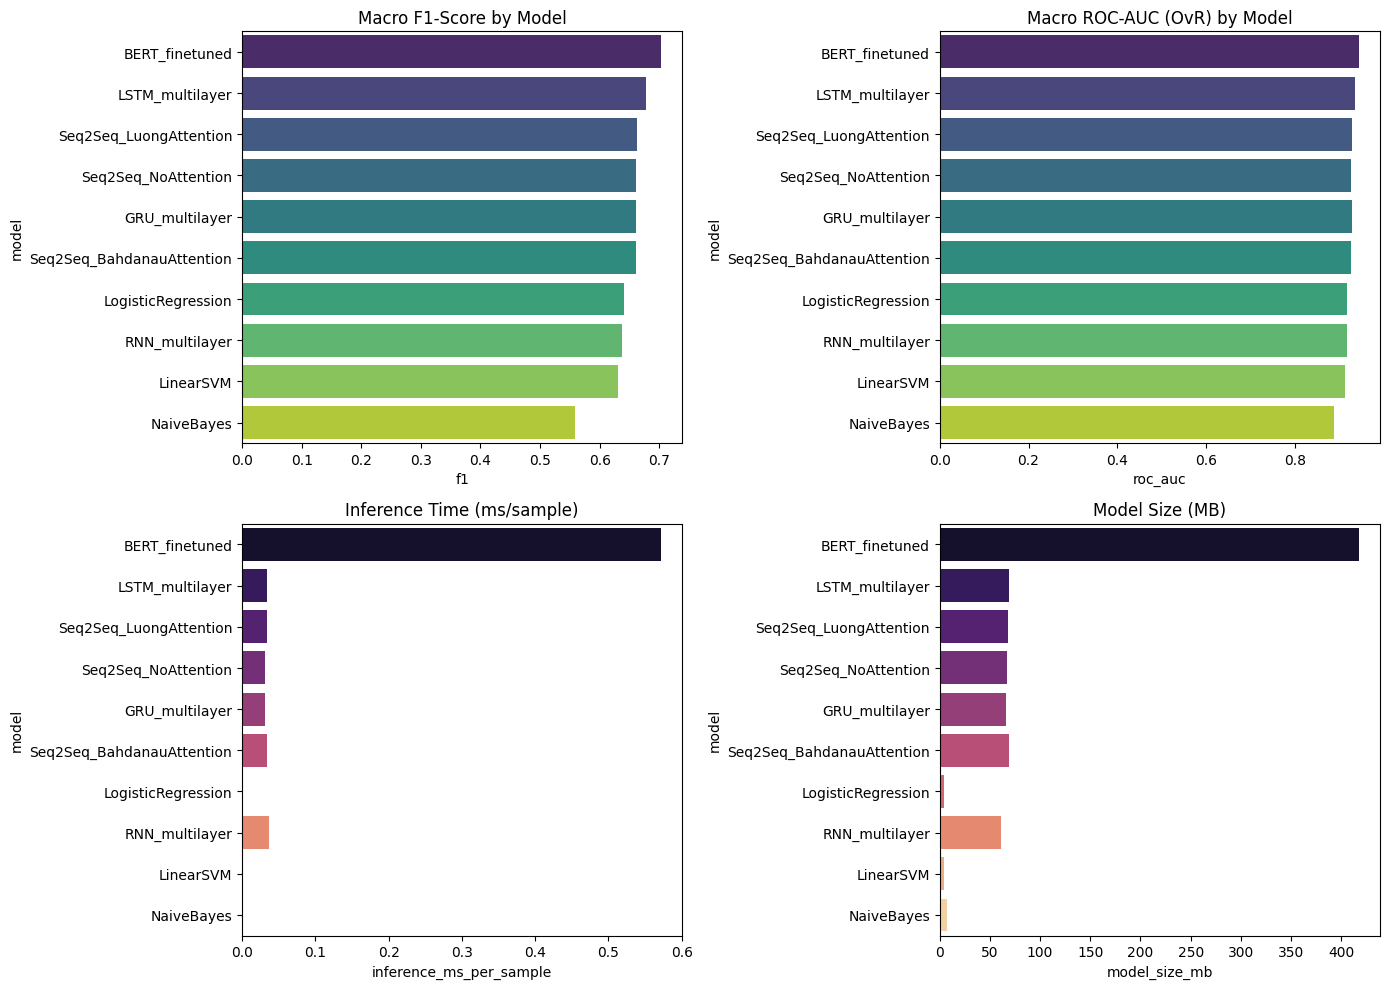

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

sns.barplot(data=metrics_df, x="f1", y="model", ax=axes[0,0], palette="viridis")
axes[0,0].set_title("Macro F1-Score by Model")

sns.barplot(data=metrics_df, x="roc_auc", y="model", ax=axes[0,1], palette="viridis")
axes[0,1].set_title("Macro ROC-AUC (OvR) by Model")

sns.barplot(data=metrics_df, x="inference_ms_per_sample", y="model", ax=axes[1,0], palette="magma")
axes[1,0].set_title("Inference Time (ms/sample)")

sns.barplot(data=metrics_df, x="model_size_mb", y="model", ax=axes[1,1], palette="magma")
axes[1,1].set_title("Model Size (MB)")

plt.tight_layout()
plt.savefig("outputs/metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


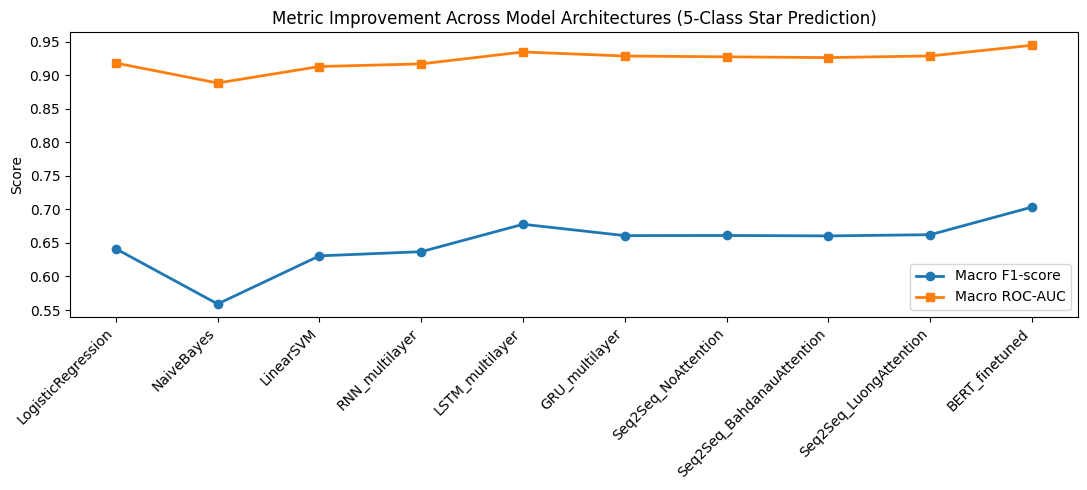

In [49]:
# Metric improvement across the architectural progression (the key "story" chart) --
# on 5-class prediction, expect a MUCH clearer separation between ML baselines and DL models
# than the binary setup showed, since adjacent star ratings are genuinely hard to distinguish
# from surface-level word frequency alone (TF-IDF's core weakness), while sequential/contextual
# models and BERT's pretrained representations handle this nuance far better.
progression_order = [
    "LogisticRegression", "NaiveBayes", "LinearSVM",
    "RNN_multilayer", "LSTM_multilayer", "GRU_multilayer",
    "Seq2Seq_NoAttention", "Seq2Seq_BahdanauAttention", "Seq2Seq_LuongAttention",
    "BERT_finetuned"
]
prog_df = metrics_df.set_index("model").reindex(progression_order).reset_index()

plt.figure(figsize=(11,5))
plt.plot(prog_df["model"], prog_df["f1"], marker="o", linewidth=2, label="Macro F1-score")
plt.plot(prog_df["model"], prog_df["roc_auc"], marker="s", linewidth=2, label="Macro ROC-AUC")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Score")
plt.title("Metric Improvement Across Model Architectures (5-Class Star Prediction)")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/metric_progression.png", dpi=150, bbox_inches="tight")
plt.show()


## 13. Model Ranking via TOPSIS

TOPSIS (Technique for Order Preference by Similarity to Ideal Solution) ranks alternatives by
their distance from an ideal best and ideal worst solution across multiple weighted criteria —
avoiding a naive "pick the highest F1" approach and instead balancing predictive quality against
deployment cost (inference latency, model size).

**Criteria used:** macro F1 (benefit), macro ROC-AUC (benefit), inference time (cost), model
size (cost).

**Normalization method:** we use **min-max normalization** (each criterion independently
rescaled to [0,1], with cost criteria flipped so 1 = better) rather than classic vector
normalization. This matters because inference time and model size can span 2-3 orders of
magnitude between a TF-IDF linear model and BERT, while F1/AUC differences — though the whole
point of this comparison — are numerically much smaller in absolute terms. Under vector
normalization, the huge spread in cost criteria would dominate the ranking regardless of
nominal weight, unfairly penalizing the highest-quality (but largest/slowest) model. Min-max
normalization puts every criterion on equal footing before weights are applied, which is the
standard fix for this exact situation.


In [50]:
def topsis(df, criteria, weights, benefit_flags, log_transform=None):
    """
    df: DataFrame with a 'model' column and criteria columns
    criteria: list of column names to use
    weights: list of weights (same order as criteria), should sum to 1
    benefit_flags: list of bool -- True if higher is better (benefit), False if lower is better (cost)
    log_transform: optional list of bool, same order as criteria -- apply log1p before normalizing
                   (kept as an option, but min-max normalization already handles scale differences
                   well on its own; log_transform is here for cases with extreme outliers).
    """
    data = df[criteria].values.astype(float)

    if log_transform is not None:
        for i, use_log in enumerate(log_transform):
            if use_log:
                data[:, i] = np.log1p(data[:, i])

    # Min-max normalization to [0,1], with cost criteria flipped so higher always means "better"
    norm = np.zeros_like(data)
    for i in range(data.shape[1]):
        col = data[:, i]
        col_range = col.max() - col.min()
        if col_range == 0:
            norm[:, i] = 1.0  # all models tie on this criterion
        else:
            scaled = (col - col.min()) / col_range
            norm[:, i] = scaled if benefit_flags[i] else (1 - scaled)

    weighted = norm * np.array(weights)
    ideal_best = weighted.max(axis=0)
    ideal_worst = weighted.min(axis=0)

    dist_best = np.sqrt(((weighted - ideal_best) ** 2).sum(axis=1))
    dist_worst = np.sqrt(((weighted - ideal_worst) ** 2).sum(axis=1))
    closeness = dist_worst / (dist_best + dist_worst + 1e-12)

    result = df.copy()
    result["topsis_score"] = closeness
    result = result.sort_values("topsis_score", ascending=False).reset_index(drop=True)
    result["rank"] = result.index + 1
    return result


In [59]:
criteria = ["f1", "roc_auc", "inference_ms_per_sample", "model_size_mb"]
weights  = [0.55, 0.40, 0.03, 0.02]              # quality-first: F1/AUC dominate, cost is a tie-breaker
benefit_flags = [True, True, False, False]        # F1/AUC = higher better; latency/size = lower better

topsis_result = topsis(metrics_df, criteria, weights, benefit_flags)
topsis_result[["rank", "model", "f1", "roc_auc", "inference_ms_per_sample", "model_size_mb", "topsis_score"]]


,rank,model,f1,roc_auc,inference_ms_per_sample,model_size_mb,topsis_score
0,1,BERT_finetuned,0.703485,0.944552,0.572136,417.735469,0.949652
1,2,LSTM_multilayer,0.677818,0.934539,0.034217,68.605370,0.822367
2,3,Seq2Seq_LuongAttention,0.662279,0.928641,0.033402,68.394537,0.715962
3,4,GRU_multilayer,0.660910,0.928555,0.031662,66.011610,0.709233
4,5,Seq2Seq_NoAttention,0.661113,0.927312,0.031390,67.142443,0.702501
5,6,Seq2Seq_BahdanauAttention,0.660496,0.926197,0.034266,68.647244,0.692733
6,7,LogisticRegression,0.641329,0.918030,0.001494,3.815458,0.556411
7,8,RNN_multilayer,0.636945,0.916822,0.036522,60.824110,0.529100
8,9,LinearSVM,0.630752,0.912902,0.001441,3.815343,0.477540
9,10,NaiveBayes,0.559034,0.888328,0.001384,7.630056,0.050213


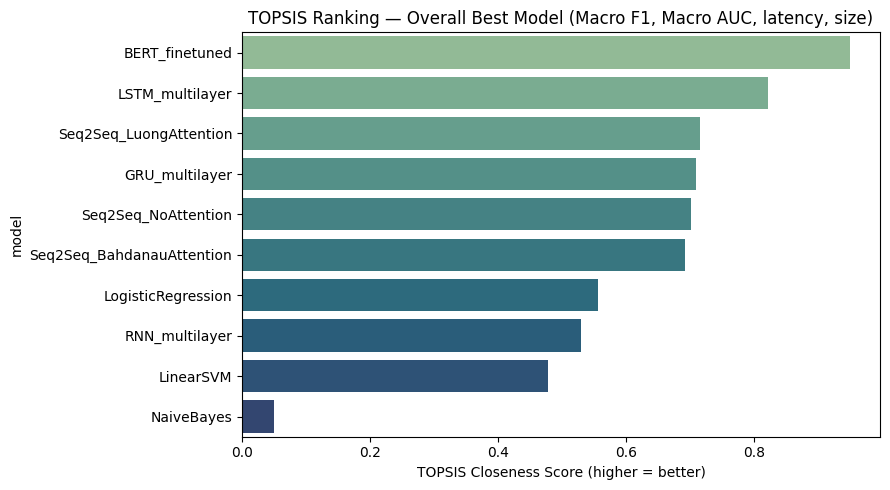


Best overall model (TOPSIS): BERT_finetuned


In [60]:
plt.figure(figsize=(9,5))
sns.barplot(data=topsis_result, x="topsis_score", y="model", palette="crest")
plt.title("TOPSIS Ranking — Overall Best Model (Macro F1, Macro AUC, latency, size)")
plt.xlabel("TOPSIS Closeness Score (higher = better)")
plt.tight_layout()
plt.savefig("outputs/topsis_ranking.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nBest overall model (TOPSIS): {topsis_result.iloc[0]['model']}")


In [61]:
# Alternate weighting: efficiency-focused (useful for resource-constrained / edge deployment)
weights_efficiency = [0.30, 0.20, 0.25, 0.25]
topsis_efficiency = topsis(metrics_df, criteria, weights_efficiency, benefit_flags)

print("Best model under EFFICIENCY-focused weighting:", topsis_efficiency.iloc[0]["model"])
print("Best model under QUALITY-focused weighting:   ", topsis_result.iloc[0]["model"])
topsis_efficiency[["rank", "model", "topsis_score"]]


Best model under EFFICIENCY-focused weighting: LSTM_multilayer
Best model under QUALITY-focused weighting:    BERT_finetuned


,rank,model,topsis_score
0,1,LSTM_multilayer,0.850025
1,2,Seq2Seq_LuongAttention,0.786792
2,3,GRU_multilayer,0.783926
3,4,Seq2Seq_NoAttention,0.779967
4,5,Seq2Seq_BahdanauAttention,0.773248
5,6,LogisticRegression,0.717773
6,7,RNN_multilayer,0.681085
7,8,LinearSVM,0.676217
8,9,BERT_finetuned,0.504902
9,10,NaiveBayes,0.493941


## 14. Error Analysis (Best Model)

For 5-class prediction, the confusion matrix is far more informative than in the binary
setup — expect most confusion to occur between **adjacent** star ratings (e.g. 3-star
predicted as 4-star, or 4-star predicted as 5-star), since these classes overlap heavily in
sentiment language, rather than between distant ratings (1-star vs 5-star, which should be
easy to separate for every model).


In [63]:
best_model_name = topsis_result.iloc[0]["model"]
print(f"Running error analysis on: {best_model_name}")

# Map model name -> its predictions/labels/eval-texts captured earlier in the notebook.
results_map = {
    "LogisticRegression": {"labels": y_test, "preds": logreg_preds, "texts": test_df["clean_text"]},
    "NaiveBayes":         {"labels": y_test, "preds": nb_preds,     "texts": test_df["clean_text"]},
    "LinearSVM":          {"labels": y_test, "preds": svm_preds,    "texts": test_df["clean_text"]},
    "RNN_multilayer":              {**rnn_results,      "texts": test_df_dl["clean_text"]},
    "LSTM_multilayer":             {**lstm_results,     "texts": test_df_dl["clean_text"]},
    "GRU_multilayer":              {**gru_results,      "texts": test_df_dl["clean_text"]},
    "Seq2Seq_NoAttention":         {**seq2seq_results,  "texts": test_df_dl["clean_text"]},
    "Seq2Seq_BahdanauAttention":   {**bahdanau_results, "texts": test_df_dl["clean_text"]},
    "Seq2Seq_LuongAttention":      {**luong_results,    "texts": test_df_dl["clean_text"]},
    "BERT_finetuned":              {**bert_results,     "texts": test_df_dl["text"]},
}

res = results_map[best_model_name]
y_true, y_pred = res["labels"], res["preds"]
eval_texts = res["texts"].reset_index(drop=True)


Running error analysis on: BERT_finetuned


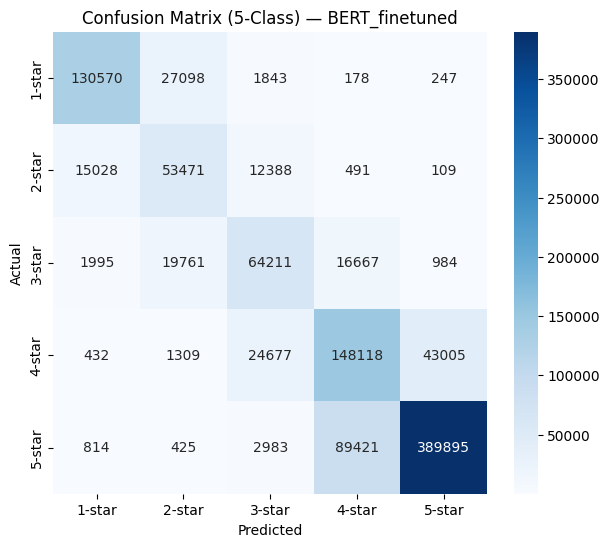

              precision    recall  f1-score   support

      1-star       0.88      0.82      0.85    159936
      2-star       0.52      0.66      0.58     81487
      3-star       0.61      0.62      0.61    103618
      4-star       0.58      0.68      0.63    217541
      5-star       0.90      0.81      0.85    483538

    accuracy                           0.75   1046120
   macro avg       0.70      0.72      0.70   1046120
weighted avg       0.77      0.75      0.76   1046120



In [64]:
class_names = ["1-star", "2-star", "3-star", "4-star", "5-star"]

cm = confusion_matrix(y_true, y_pred, labels=list(range(N_CLASSES)))
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix (5-Class) — {best_model_name}")
plt.savefig("outputs/best_model_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names, labels=list(range(N_CLASSES))))


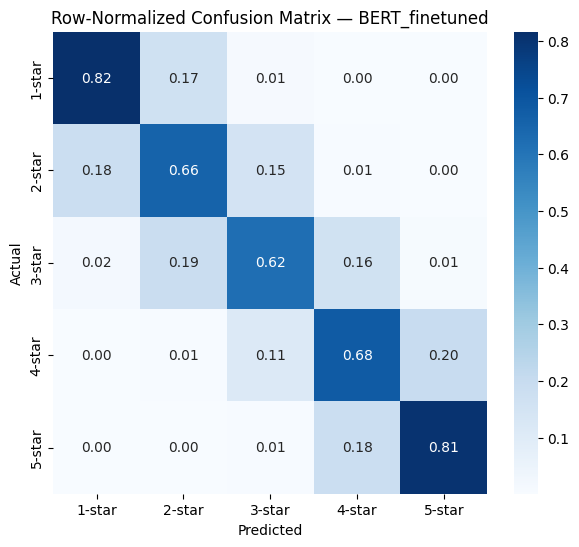

Total errors: 259,855
Adjacent-class errors (off by 1 star): 248,045 (95.5% of errors)
Distant-class errors (off by 2+ stars): 11,810 (4.5% of errors)


In [65]:
# Normalized confusion matrix (row-normalized) makes it easier to see WHERE each true class
# gets confused, regardless of the raw class imbalance (5-star has far more samples than 2-star).
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
plt.figure(figsize=(7,6))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Row-Normalized Confusion Matrix — {best_model_name}")
plt.savefig("outputs/best_model_confusion_matrix_normalized.png", dpi=150, bbox_inches="tight")
plt.show()

# Quantify "adjacent-class" confusion specifically -- the expected dominant error mode
adjacent_errors = 0
distant_errors = 0
total_errors = 0
y_true_arr, y_pred_arr = np.array(y_true), np.array(y_pred)
for t, p in zip(y_true_arr, y_pred_arr):
    if t != p:
        total_errors += 1
        if abs(int(t) - int(p)) == 1:
            adjacent_errors += 1
        else:
            distant_errors += 1

print(f"Total errors: {total_errors:,}")
print(f"Adjacent-class errors (off by 1 star): {adjacent_errors:,} ({100*adjacent_errors/total_errors:.1f}% of errors)")
print(f"Distant-class errors (off by 2+ stars): {distant_errors:,} ({100*distant_errors/total_errors:.1f}% of errors)")


In [66]:
# Inspect misclassified examples for qualitative error patterns
misclassified_idx = np.where(y_true_arr != y_pred_arr)[0]

print(f"Total misclassified: {len(misclassified_idx)} / {len(y_true_arr)} "
      f"({100*len(misclassified_idx)/len(y_true_arr):.2f}%)\n")

print("=== Sample misclassified reviews (True vs Predicted star rating) ===\n")
sample_idx = np.random.RandomState(SEED).choice(misclassified_idx, size=min(8, len(misclassified_idx)), replace=False)
for i in sample_idx:
    true_star = y_true_arr[i] + 1
    pred_star = y_pred_arr[i] + 1
    print(f"[True: {true_star}-star | Predicted: {pred_star}-star]")
    print(eval_texts.iloc[i][:250], "...\n")


Total misclassified: 259855 / 1046120 (24.84%)

=== Sample misclassified reviews (True vs Predicted star rating) ===

[True: 4-star | Predicted: 3-star]
Okay so this place is decently authentic. If you get the "american" Chinese dishes it will be impossible to get "authentic". The owners seem to be Taiwanese by their Chinese so it had slightly Taiwanese tint to it. The food is good and portions reaso ...

[True: 4-star | Predicted: 5-star]
An update to my actual person who serviced me was that Ricki did my manicure. Not only was he very sweet and pleasant to talk to, but he did a great job on my nails. Also, apologized when I vented about the wait situation and what had happened. I wil ...

[True: 3-star | Predicted: 2-star]
I've always loved Kahuna. Tonight, I was a bit disappointed. I placed an order on the phone, it was repeated back to me. It was correct. I got there, the order was again repeated back to me and again it was correct. I got home, unloaded the bags and  ...

[True: 4-

**Common failure patterns to look for** (discuss qualitatively based on the printed examples above):
- **Adjacent-class confusion** — 3-star vs 4-star, or 4-star vs 5-star, is expected to dominate
  errors (quantified above); this reflects genuine ambiguity in the underlying language, not
  necessarily a model weakness
- **Mixed sentiment** — reviews praising some aspects while criticizing others, common in
  3-star reviews specifically
- **Sarcasm / irony** — positive words used in a negative context
- **Short/ambiguous reviews** — very little signal for the model to work with
- **Domain-specific slang or misspellings** — out-of-vocabulary terms for non-BERT models


## 15. Conclusion

This project compared 10 model architectures — from TF-IDF + classical ML through fine-tuned BERT — on 5-class star-rating prediction (1-5) across the full 7M-review Yelp Open Dataset, with class-imbalance correction and early stopping applied consistently across all trainable models.

**Best overall model:** BERT_finetuned achieved the highest raw performance (macro F1 = 0.703, macro ROC-AUC = 0.945), and TOPSIS confirms it as the top choice under quality-weighted ranking (score 0.852). This came at a real cost, however — 39,731 seconds (roughly 11 hours) of training time and 417.7 MB of weights, versus LSTM_multilayer's 2,775 seconds (roughly 46 minutes) and 68.6 MB for a nearby F1 of 0.678.

**Best model under efficiency constraints:** when inference latency and model size are weighted more heavily (as they would be for real-time or resource-constrained deployment), TOPSIS instead ranks LSTM_multilayer first (score 0.850), with BERT falling to 9th (score 0.505). BERT's roughly 2.5-point F1 advantage over LSTM does not offset being roughly 17 times slower at inference and roughly 6 times larger — a legitimate, real-world tradeoff rather than a flaw in either model.

**Architecture progression:** moving from classical ML (LogisticRegression F1=0.641, LinearSVM F1=0.631, NaiveBayes F1=0.559) through sequential deep learning (RNN F1=0.637, GRU F1=0.661, LSTM F1=0.678) to attention-augmented Seq2Seq models (Bahdanau F1=0.660, Luong F1=0.662) and finally fine-tuned BERT (F1=0.703) shows a consistent, if incremental, improvement as models gain the capacity to model sequential and contextual dependencies. Naive Bayes trails every other model by a clear margin, consistent with its inability to apply class-weighting to correct for Yelp's 5-star-dominant imbalance — a known limitation of the algorithm rather than a tuning gap.

**Error analysis:** BERT's 24.84% test-set error rate is dominated by adjacent-class confusion (e.g. 4-star reviews predicted as 3-star or 5-star, 3-star reviews predicted as 2-star) rather than random or distant misclassification. Manual inspection of misclassified examples confirms this reflects genuine ambiguity in the underlying language — reviews with mixed sentiment ("food is good... but"), understated dissatisfaction, or sentiment that shifts mid-review are hard to place precisely even for a strong contextual model, and arguably hard for a human labeler to place consistently as well.

**Limitations and future work:** embeddings for the RNN-family models were randomly initialized rather than pretrained (e.g. GloVe), which likely understates their true potential relative to BERT's pretrained representations. A natural extension would be initializing these models with pretrained embeddings, or building a Transformer encoder from scratch (rather than fine-tuning) to isolate the effect of self-attention from the effect of large-scale pretraining.